In [7]:
import pandas as pd

# Charger ton fichier téléchargé
df = pd.read_csv('frequentation-gares.csv', sep=';')



In [8]:
print(df.columns.tolist())

['Nom de la gare', 'Code UIC', 'Code postal', 'Direction Régionale Gares', 'Segmentation DRG', 'Segmentation Marketing', '% Non Voyageurs', 'Total Voyageurs 2024', 'Total Voyageurs + Non voyageurs 2024', 'Total Voyageurs 2023', 'Total Voyageurs + Non voyageurs 2023', 'Total Voyageurs 2022', 'Total Voyageurs + Non voyageurs 2022', 'Total Voyageurs 2021', 'Total Voyageurs + Non voyageurs 2021', 'Total Voyageurs 2020', 'Total Voyageurs + Non voyageurs 2020', 'Total Voyageurs 2019', 'Total Voyageurs + Non voyageurs 2019', 'Total Voyageurs 2018', 'Total Voyageurs + Non voyageurs 2018', 'Total Voyageurs 2017', 'Total Voyageurs + Non voyageurs 2017', 'Total Voyageurs 2016', 'Total Voyageurs + Non voyageurs 2016', 'Total Voyageurs 2015', 'Total Voyageurs + Non voyageurs 2015']


In [9]:
import pandas as pd

# 1. Chargement (ajuste le nom du fichier si nécessaire)
df = pd.read_csv('frequentation-gares.csv', sep=';')

# 2. Paramètres de calcul (Sources : ADEME / ONISR)
DIST_MOYENNE = 45 # km moyen par voyageur
CO2_EVITE_KG_KM = 0.187 # kg de CO2 évité par km (comparé à la voiture)
NB_MORTS_VOITURE_PAR_KM = 3.1 / 1e9 # 3.1 décès pour 1 milliard de km passager

# 3. Calculs des indicateurs
# On utilise 'Total Voyageurs 2024' qui est ta donnée la plus récente
col_ref = 'Total Voyageurs 2024'

# A. CO2 Évité (en tonnes)
df['CO2_evite_t'] = (df[col_ref] * DIST_MOYENNE * CO2_EVITE_KG_KM) / 1000

# B. Vies épargnées (Modèle statistique théorique)
# On calcule combien de décès auraient eu lieu si ces km étaient faits en voiture
df['Vies_sauvees_stat'] = df[col_ref] * DIST_MOYENNE * NB_MORTS_VOITURE_PAR_KM

# C. Gain d'espace urbain (en m2)
# Basé sur l'idée qu'un parking de gare est plus efficace que des milliers de places en ville
df['Espace_urbain_gagne_m2'] = df[col_ref] * 0.02 

# 4. Tri par impact écologique
df_resultat = df[['Nom de la gare', col_ref, 'CO2_evite_t', 'Vies_sauvees_stat']].sort_values(by='CO2_evite_t', ascending=False)

# Affichage des 10 premiers résultats
print("Top 10 des gares par impact environnemental (Données 2024) :")
print(df_resultat.head(10))

# 5. Export final
df.to_csv('impact_societal_gares_2024.csv', index=False, sep=';', encoding='utf-8-sig')

Top 10 des gares par impact environnemental (Données 2024) :
              Nom de la gare  Total Voyageurs 2024   CO2_evite_t  \
291       Paris Gare du Nord             257024152  2.162858e+06   
816       Paris Saint-Lazare             114093491  9.600967e+05   
815       Paris Gare de Lyon             113224230  9.527819e+05   
2866      Paris Montparnasse              68925312  5.800065e+05   
1987               Paris Est              42725621  3.595361e+05   
656           Lyon Part Dieu              42434779  3.570887e+05   
1903         Juvisy-sur-Orge              41881077  3.524293e+05   
1701                 Magenta              38771197  3.262596e+05   
424   Haussmann Saint-Lazare              38268052  3.220257e+05   
2011             Saint-Denis              36960585  3.110233e+05   

      Vies_sauvees_stat  
291           35.854869  
816           15.916042  
815           15.794780  
2866           9.615081  
1987           5.960224  
656            5.919652  
1903    

In [10]:
import pandas as pd

# 1. Chargement (ajuste le nom du fichier si nécessaire)
df = pd.read_csv('frequentation-gares.csv', sep=';')

# 2. Paramètres de calcul (Sources : ADEME / ONISR)
DIST_MOYENNE = 45 # km moyen par voyageur
CO2_EVITE_KG_KM = 0.187 # kg de CO2 évité par km (comparé à la voiture)
NB_MORTS_VOITURE_PAR_KM = 3.1 / 1e9 # 3.1 décès pour 1 milliard de km passager

# 3. Calculs des indicateurs
# On utilise 'Total Voyageurs 2024' qui est ta donnée la plus récente
col_ref = 'Total Voyageurs 2024'

# A. CO2 Évité (en tonnes)
df['CO2_evite_t'] = (df[col_ref] * DIST_MOYENNE * CO2_EVITE_KG_KM) / 1000

# B. Vies épargnées (Modèle statistique théorique)
# On calcule combien de décès auraient eu lieu si ces km étaient faits en voiture
df['Vies_sauvees_stat'] = df[col_ref] * DIST_MOYENNE * NB_MORTS_VOITURE_PAR_KM

# C. Gain d'espace urbain (en m2)
# Basé sur l'idée qu'un parking de gare est plus efficace que des milliers de places en ville
df['Espace_urbain_gagne_m2'] = df[col_ref] * 0.02 

# 4. Tri par impact écologique
df_resultat = df[['Nom de la gare', col_ref, 'CO2_evite_t', 'Vies_sauvees_stat']].sort_values(by='CO2_evite_t', ascending=False)

# Affichage des 10 premiers résultats
print("Top 10 des gares par impact environnemental (Données 2024) :")
print(df_resultat.head(10))

# 5. Export final
df.to_csv('impact_societal_gares_2024.csv', index=False, sep=';', encoding='utf-8-sig')

Top 10 des gares par impact environnemental (Données 2024) :
              Nom de la gare  Total Voyageurs 2024   CO2_evite_t  \
291       Paris Gare du Nord             257024152  2.162858e+06   
816       Paris Saint-Lazare             114093491  9.600967e+05   
815       Paris Gare de Lyon             113224230  9.527819e+05   
2866      Paris Montparnasse              68925312  5.800065e+05   
1987               Paris Est              42725621  3.595361e+05   
656           Lyon Part Dieu              42434779  3.570887e+05   
1903         Juvisy-sur-Orge              41881077  3.524293e+05   
1701                 Magenta              38771197  3.262596e+05   
424   Haussmann Saint-Lazare              38268052  3.220257e+05   
2011             Saint-Denis              36960585  3.110233e+05   

      Vies_sauvees_stat  
291           35.854869  
816           15.916042  
815           15.794780  
2866           9.615081  
1987           5.960224  
656            5.919652  
1903    

In [11]:
import pandas as pd

# 1. Chargement (ajuste le nom du fichier si nécessaire)
df = pd.read_csv('frequentation-gares.csv', sep=';')

# 2. Paramètres de calcul (Sources : ADEME / ONISR)
DIST_MOYENNE = 45 # km moyen par voyageur
CO2_EVITE_KG_KM = 0.187 # kg de CO2 évité par km (comparé à la voiture)
NB_MORTS_VOITURE_PAR_KM = 3.1 / 1e9 # 3.1 décès pour 1 milliard de km passager

# 3. Calculs des indicateurs
# On utilise 'Total Voyageurs 2024' qui est ta donnée la plus récente
col_ref = 'Total Voyageurs 2024'

# A. CO2 Évité (en tonnes)
df['CO2_evite_t'] = (df[col_ref] * DIST_MOYENNE * CO2_EVITE_KG_KM) / 1000

# B. Vies épargnées (Modèle statistique théorique)
# On calcule combien de décès auraient eu lieu si ces km étaient faits en voiture
df['Vies_sauvees_stat'] = df[col_ref] * DIST_MOYENNE * NB_MORTS_VOITURE_PAR_KM

# C. Gain d'espace urbain (en m2)
# Basé sur l'idée qu'un parking de gare est plus efficace que des milliers de places en ville
df['Espace_urbain_gagne_m2'] = df[col_ref] * 0.02 

# 4. Tri par impact écologique
df_resultat = df[['Nom de la gare', col_ref, 'CO2_evite_t', 'Vies_sauvees_stat']].sort_values(by='CO2_evite_t', ascending=False)

# Affichage des 10 premiers résultats
print("Top 10 des gares par impact environnemental (Données 2024) :")
print(df_resultat.head(10))

# 5. Export final
df.to_csv('impact_societal_gares_2024.csv', index=False, sep=';', encoding='utf-8-sig')

Top 10 des gares par impact environnemental (Données 2024) :
              Nom de la gare  Total Voyageurs 2024   CO2_evite_t  \
291       Paris Gare du Nord             257024152  2.162858e+06   
816       Paris Saint-Lazare             114093491  9.600967e+05   
815       Paris Gare de Lyon             113224230  9.527819e+05   
2866      Paris Montparnasse              68925312  5.800065e+05   
1987               Paris Est              42725621  3.595361e+05   
656           Lyon Part Dieu              42434779  3.570887e+05   
1903         Juvisy-sur-Orge              41881077  3.524293e+05   
1701                 Magenta              38771197  3.262596e+05   
424   Haussmann Saint-Lazare              38268052  3.220257e+05   
2011             Saint-Denis              36960585  3.110233e+05   

      Vies_sauvees_stat  
291           35.854869  
816           15.916042  
815           15.794780  
2866           9.615081  
1987           5.960224  
656            5.919652  
1903    

In [12]:
df.shape


(3021, 30)

In [13]:
df.isnull().sum()


Nom de la gare                            0
Code UIC                                  0
Code postal                               0
Direction Régionale Gares                11
Segmentation DRG                         70
Segmentation Marketing                  125
% Non Voyageurs                           0
Total Voyageurs 2024                      0
Total Voyageurs + Non voyageurs 2024      0
Total Voyageurs 2023                      0
Total Voyageurs + Non voyageurs 2023      0
Total Voyageurs 2022                      0
Total Voyageurs + Non voyageurs 2022      0
Total Voyageurs 2021                      0
Total Voyageurs + Non voyageurs 2021      0
Total Voyageurs 2020                      0
Total Voyageurs + Non voyageurs 2020      0
Total Voyageurs 2019                      0
Total Voyageurs + Non voyageurs 2019      0
Total Voyageurs 2018                      0
Total Voyageurs + Non voyageurs 2018      0
Total Voyageurs 2017                      0
Total Voyageurs + Non voyageurs 

<Axes: >

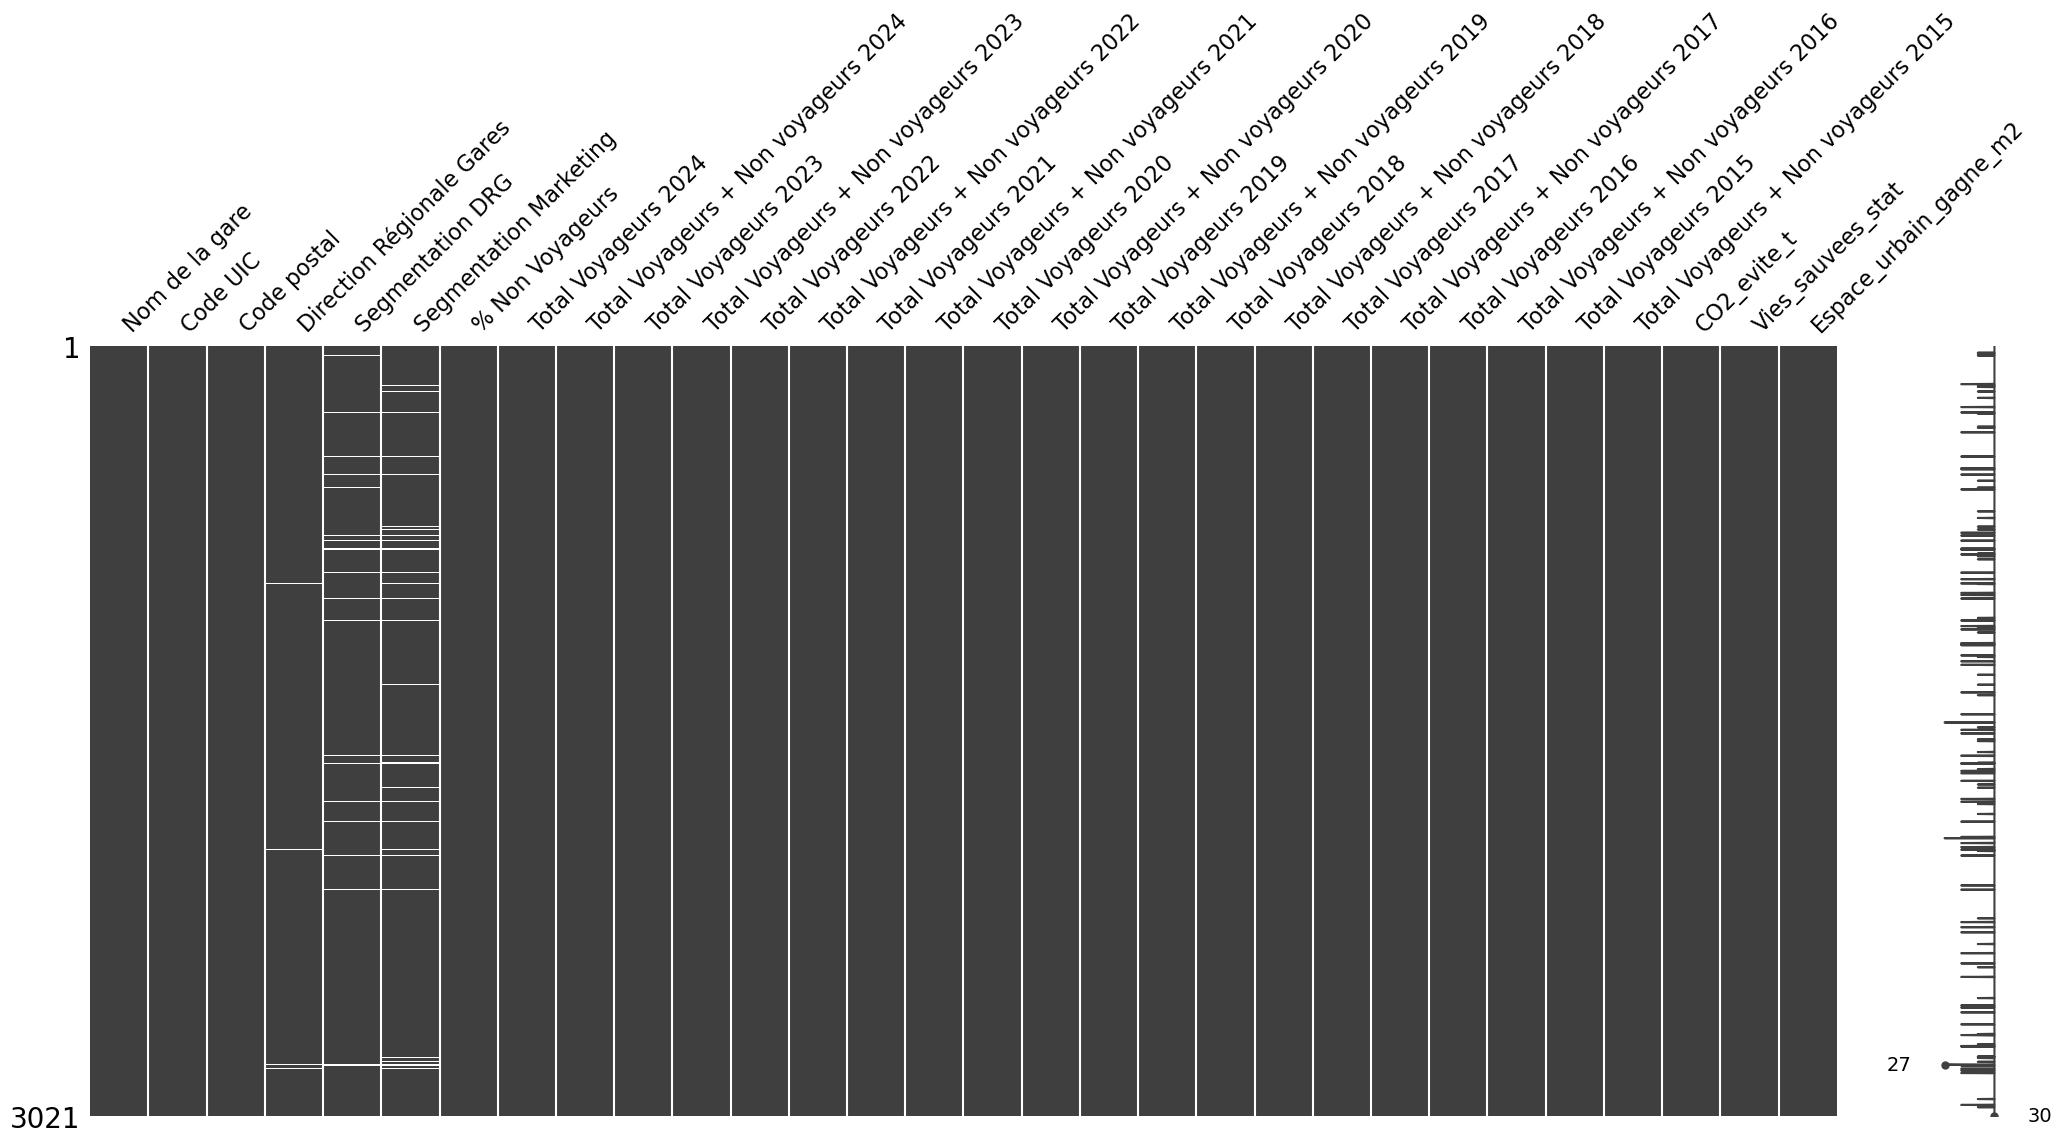

In [14]:
import missingno as msno
msno.matrix(df)

In [15]:
# 1. Pour les colonnes de texte (Object)
cols_texte = df.select_dtypes(include=['object']).columns
df[cols_texte] = df[cols_texte].fillna("pas de donnees")

# 2. Pour les colonnes numériques (Fréquentation, etc.)
# Option A : Mettre 0 (pour pouvoir faire des stats)
cols_num = df.select_dtypes(include=['number']).columns
df[cols_num] = df[cols_num].fillna(0)

# Option B : Si tu veux VRAIMENT du texte partout (attention aux calculs !)
# df = df.astype(str).fillna("pas de donnees")

In [16]:
df.isnull().sum()

Nom de la gare                          0
Code UIC                                0
Code postal                             0
Direction Régionale Gares               0
Segmentation DRG                        0
Segmentation Marketing                  0
% Non Voyageurs                         0
Total Voyageurs 2024                    0
Total Voyageurs + Non voyageurs 2024    0
Total Voyageurs 2023                    0
Total Voyageurs + Non voyageurs 2023    0
Total Voyageurs 2022                    0
Total Voyageurs + Non voyageurs 2022    0
Total Voyageurs 2021                    0
Total Voyageurs + Non voyageurs 2021    0
Total Voyageurs 2020                    0
Total Voyageurs + Non voyageurs 2020    0
Total Voyageurs 2019                    0
Total Voyageurs + Non voyageurs 2019    0
Total Voyageurs 2018                    0
Total Voyageurs + Non voyageurs 2018    0
Total Voyageurs 2017                    0
Total Voyageurs + Non voyageurs 2017    0
Total Voyageurs 2016              

In [17]:
import pandas as pd

# 1. Chargement
df = pd.read_csv('frequentation-gares.csv', sep=';')

# 2. Paramètres
DIST_MOYENNE = 45 
CO2_EVITE_KG_KM = 0.187 

# 3. Calculs des colonnes (CO2 et Evolution)
# On s'assure que les colonnes sont bien lues comme des nombres
df['Total Voyageurs 2024'] = pd.to_numeric(df['Total Voyageurs 2024'], errors='coerce').fillna(0)
df['Total Voyageurs 2023'] = pd.to_numeric(df['Total Voyageurs 2023'], errors='coerce').fillna(0)

# Ajout du CO2
df['CO2_evite_t'] = (df['Total Voyageurs 2024'] * DIST_MOYENNE * CO2_EVITE_KG_KM) / 1000

# Ajout de l'évolution
df['Evolution_Absolue'] = df['Total Voyageurs 2024'] - df['Total Voyageurs 2023']

# 4. Remplissage des valeurs manquantes par "pas de donnees"
# On transforme d'abord tout en texte pour accepter le message "pas de donnees"
df = df.astype(str).replace('nan', 'pas de donnees').replace('0.0', 'pas de donnees')

# 5. ENREGISTREMENT (C'est cette étape qui crée le fichier physique)
# On change le nom pour être sûr de ne pas confondre avec l'ancien
nom_fichier_final = 'sncf_analyse_complete_2026.csv'
df.to_csv(nom_fichier_final, index=False, sep=';', encoding='utf-8-sig')

print(f"Succès ! Le fichier '{nom_fichier_final}' a été généré avec toutes les colonnes.")



Succès ! Le fichier 'sncf_analyse_complete_2026.csv' a été généré avec toutes les colonnes.


In [18]:
df.columns


Index(['Nom de la gare', 'Code UIC', 'Code postal',
       'Direction Régionale Gares', 'Segmentation DRG',
       'Segmentation Marketing', '% Non Voyageurs', 'Total Voyageurs 2024',
       'Total Voyageurs + Non voyageurs 2024', 'Total Voyageurs 2023',
       'Total Voyageurs + Non voyageurs 2023', 'Total Voyageurs 2022',
       'Total Voyageurs + Non voyageurs 2022', 'Total Voyageurs 2021',
       'Total Voyageurs + Non voyageurs 2021', 'Total Voyageurs 2020',
       'Total Voyageurs + Non voyageurs 2020', 'Total Voyageurs 2019',
       'Total Voyageurs + Non voyageurs 2019', 'Total Voyageurs 2018',
       'Total Voyageurs + Non voyageurs 2018', 'Total Voyageurs 2017',
       'Total Voyageurs + Non voyageurs 2017', 'Total Voyageurs 2016',
       'Total Voyageurs + Non voyageurs 2016', 'Total Voyageurs 2015',
       'Total Voyageurs + Non voyageurs 2015', 'CO2_evite_t',
       'Evolution_Absolue'],
      dtype='object')

In [19]:
import pandas as pd

# 1. Chargement du fichier
df = pd.read_csv('frequentation-gares.csv', sep=';')

# 2. Paramètres de calcul
DIST_MOYENNE = 45 # km moyen par voyageur
CO2_EVITE_KG_KM = 0.187 # kg de CO2 évité par km
NB_MORTS_VOITURE_PAR_KM = 3.1 / 1e9 # Statistique ONISR

# 3. Boucle de calcul pour chaque année (2015 à 2024)
# (Note : 2025 n'est pas encore présent dans les données Open Data SNCF)
annees = range(2015, 2025)

for annee in annees:
    col_voyageurs = f'Total Voyageurs {annee}'
    
    if col_voyageurs in df.columns:
        # Conversion en nombre (remplace les vides par 0 pour le calcul)
        temp_calcul = pd.to_numeric(df[col_voyageurs], errors='coerce').fillna(0)
        
        # Calcul CO2 évité pour cette année (en tonnes)
        df[f'CO2_evite_t_{annee}'] = (temp_calcul * DIST_MOYENNE * CO2_EVITE_KG_KM) / 1000
        
        # Calcul Vies sauvées pour cette année (statistique)
        df[f'Vies_sauvees_stat_{annee}'] = temp_calcul * DIST_MOYENNE * NB_MORTS_VOITURE_PAR_KM

# 4. Remplissage des valeurs manquantes par "pas de donnees"
# On transforme tout en texte pour permettre l'insertion du message
df = df.astype(str).replace(['nan', 'NaN', '0.0', '0'], 'pas de donnees')

# 5. Sauvegarde du fichier final
df.to_csv('impact_annuel_2015_2025.csv', index=False, sep=';', encoding='utf-8-sig')

print("Analyse terminée ! Le fichier 'impact_annuel_2015_2025.csv' a été créé.")

Analyse terminée ! Le fichier 'impact_annuel_2015_2025.csv' a été créé.


In [20]:
df.columns


Index(['Nom de la gare', 'Code UIC', 'Code postal',
       'Direction Régionale Gares', 'Segmentation DRG',
       'Segmentation Marketing', '% Non Voyageurs', 'Total Voyageurs 2024',
       'Total Voyageurs + Non voyageurs 2024', 'Total Voyageurs 2023',
       'Total Voyageurs + Non voyageurs 2023', 'Total Voyageurs 2022',
       'Total Voyageurs + Non voyageurs 2022', 'Total Voyageurs 2021',
       'Total Voyageurs + Non voyageurs 2021', 'Total Voyageurs 2020',
       'Total Voyageurs + Non voyageurs 2020', 'Total Voyageurs 2019',
       'Total Voyageurs + Non voyageurs 2019', 'Total Voyageurs 2018',
       'Total Voyageurs + Non voyageurs 2018', 'Total Voyageurs 2017',
       'Total Voyageurs + Non voyageurs 2017', 'Total Voyageurs 2016',
       'Total Voyageurs + Non voyageurs 2016', 'Total Voyageurs 2015',
       'Total Voyageurs + Non voyageurs 2015', 'CO2_evite_t_2015',
       'Vies_sauvees_stat_2015', 'CO2_evite_t_2016', 'Vies_sauvees_stat_2016',
       'CO2_evite_t_2017', 'Vie

In [21]:
df

,Nom de la gare,Code UIC,Code postal,Direction Régionale Gares,Segmentation DRG,Segmentation Marketing,% Non Voyageurs,Total Voyageurs 2024,Total Voyageurs + Non voyageurs 2024,Total Voyageurs 2023,...,CO2_evite_t_2020,Vies_sauvees_stat_2020,CO2_evite_t_2021,Vies_sauvees_stat_2021,CO2_evite_t_2022,Vies_sauvees_stat_2022,CO2_evite_t_2023,Vies_sauvees_stat_2023,CO2_evite_t_2024,Vies_sauvees_stat_2024
0,Les Coquetiers,87113845,93250,DEX GIF,B,IDF,pas de donnees,1386734,1386734,1257508,...,13617.28764,0.225741132,7968.323385,0.1320952005,9944.468325,0.1648548225,10581.929820000001,0.175422366,11669.36661,0.193449393
1,Les Eyzies-de-Tayac-Sireuil,87595736,24620,DRG NLLE AQUITAINE,C,Proximité,pas de donnees,19660,19660,19771,...,88.534215,0.0014676795000000001,103.916835,0.0017226855,152.454555,0.0025273215,166.372965,0.0027580545,165.4389,0.00274257
2,Libercourt,87345256,62820,DRG HDF-NORMANDIE,B,Proximité,0.2,964100,1205125,886480,...,4630.15179,0.076756527,5045.0786100000005,0.083634993,6520.31226,0.108090738,7459.7292,0.12366396,8112.9015,0.13449195
3,Lille Europe,87223263,59777,DRG HDF-NORMANDIE,A,Hub,0.37,6642464,10543594,6721133,...,27796.226039999998,0.460793052,36503.15922,0.605132586,50968.805085,0.8449374105,56558.334195,0.9375980535,55896.33456,0.926623728
4,L'Isle-sur-le-Doubs,87184572,25250,DRG AURA BFC,C,Halte,pas de donnees,132116,132116,125662,...,729.83295,0.012098835,815.674365,0.0135218745,1038.1837950000001,0.0172105335,1057.44573,0.017529849,1111.75614,0.018430182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3016,Vierzon,87576009,18100,DRG B-CVL-PDL,A,Ville,0.2,1376111,1720139,1300450,...,4906.929555,0.0813448215,6868.482884999999,0.1138625505,9423.529335000001,0.1562189355,10943.28675,0.181412775,11579.974065,0.1919674845
3017,Villiers-sur-Marne - Le Plessis-Trévise,87113795,94350,DEX GIF,B,IDF,pas de donnees,9034899,9034899,8193562,...,30840.183989999998,0.511254387,47572.208145000004,0.7886301885,64801.54197,1.074250161,68948.82423,1.143001899,76028.675085,1.2603684105
3018,Vitry-en-Artois,87342113,62490,DRG HDF-NORMANDIE,C,Halte,pas de donnees,93438,93438,77456,...,516.184515,0.0085570695,560.67462,0.009294606,664.09497,0.011009061,651.79224,0.010805112,786.2807700000001,0.013034601
3019,Vivoin - Beaumont,87396077,72170,DRG B-CVL-PDL,C,Halte,pas de donnees,45002,45002,43826,...,208.380645,0.0034544385,251.398125,0.0041675625,349.214085,0.0057891105,368.79578999999995,0.006113727,378.69183000000004,0.006277779


<Axes: >

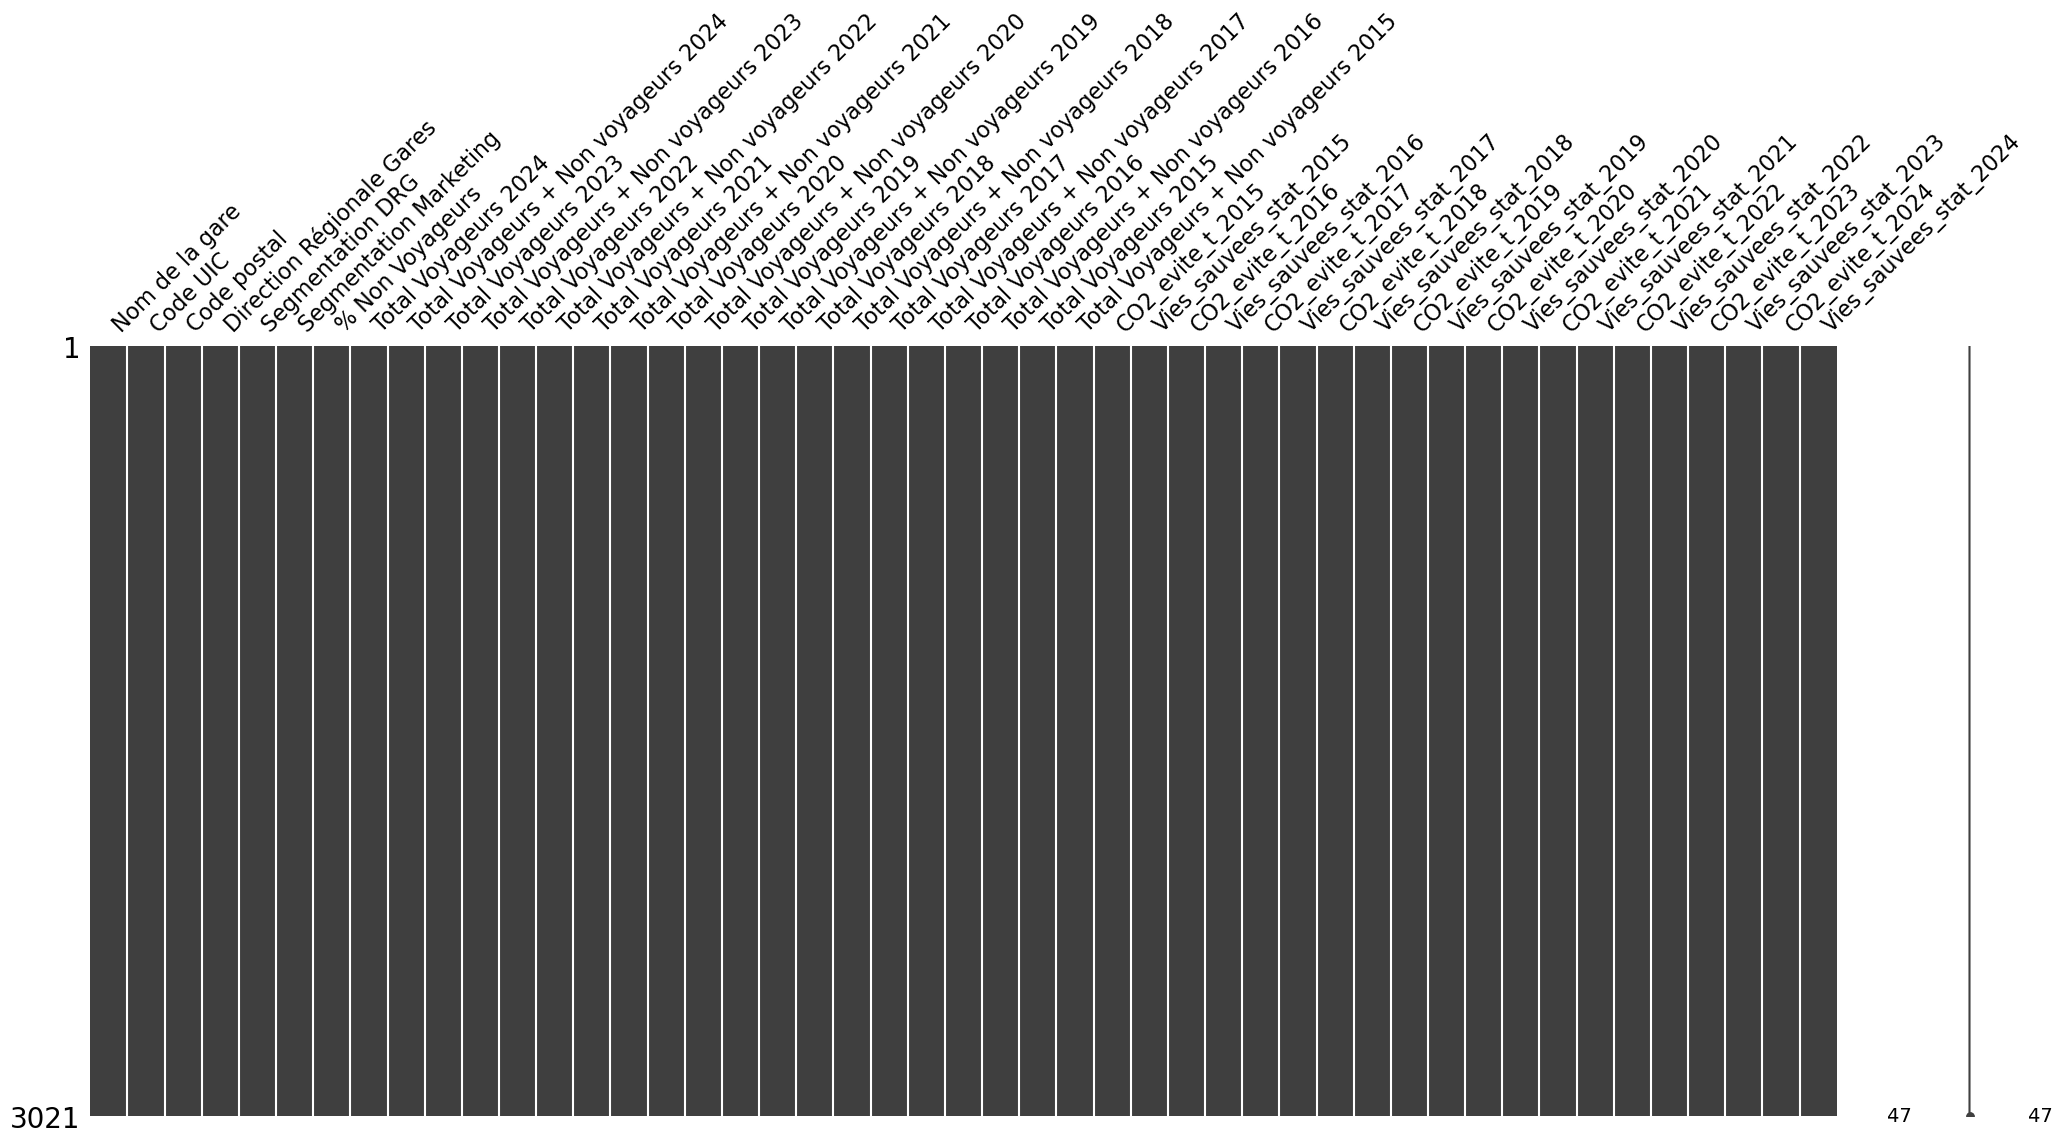

In [23]:
msno.matrix(df)

In [30]:
# Source - https://stackoverflow.com/a/14432914
# Posted by Andy Hayden, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-05, License - CC BY-SA 4.0

import sqlite3
# Create your connection.
cnx = sqlite3.connect('france_ville.db')


In [31]:


df.to_sql(name='train_france', con=cnx)


3021

In [28]:


p2 = pd.read_sql('select * from train_france', cnx)


In [29]:
p2

,index,Nom de la gare,Code UIC,Code postal,Direction Régionale Gares,Segmentation DRG,Segmentation Marketing,% Non Voyageurs,Total Voyageurs 2024,Total Voyageurs + Non voyageurs 2024,...,CO2_evite_t_2020,Vies_sauvees_stat_2020,CO2_evite_t_2021,Vies_sauvees_stat_2021,CO2_evite_t_2022,Vies_sauvees_stat_2022,CO2_evite_t_2023,Vies_sauvees_stat_2023,CO2_evite_t_2024,Vies_sauvees_stat_2024
0,0,Les Coquetiers,87113845,93250,DEX GIF,B,IDF,pas de donnees,1386734,1386734,...,13617.28764,0.225741132,7968.323385,0.1320952005,9944.468325,0.1648548225,10581.929820000001,0.175422366,11669.36661,0.193449393
1,1,Les Eyzies-de-Tayac-Sireuil,87595736,24620,DRG NLLE AQUITAINE,C,Proximité,pas de donnees,19660,19660,...,88.534215,0.0014676795000000001,103.916835,0.0017226855,152.454555,0.0025273215,166.372965,0.0027580545,165.4389,0.00274257
2,2,Libercourt,87345256,62820,DRG HDF-NORMANDIE,B,Proximité,0.2,964100,1205125,...,4630.15179,0.076756527,5045.0786100000005,0.083634993,6520.31226,0.108090738,7459.7292,0.12366396,8112.9015,0.13449195
3,3,Lille Europe,87223263,59777,DRG HDF-NORMANDIE,A,Hub,0.37,6642464,10543594,...,27796.226039999998,0.460793052,36503.15922,0.605132586,50968.805085,0.8449374105,56558.334195,0.9375980535,55896.33456,0.926623728
4,4,L'Isle-sur-le-Doubs,87184572,25250,DRG AURA BFC,C,Halte,pas de donnees,132116,132116,...,729.83295,0.012098835,815.674365,0.0135218745,1038.1837950000001,0.0172105335,1057.44573,0.017529849,1111.75614,0.018430182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3016,3016,Vierzon,87576009,18100,DRG B-CVL-PDL,A,Ville,0.2,1376111,1720139,...,4906.929555,0.0813448215,6868.482884999999,0.1138625505,9423.529335000001,0.1562189355,10943.28675,0.181412775,11579.974065,0.1919674845
3017,3017,Villiers-sur-Marne - Le Plessis-Trévise,87113795,94350,DEX GIF,B,IDF,pas de donnees,9034899,9034899,...,30840.183989999998,0.511254387,47572.208145000004,0.7886301885,64801.54197,1.074250161,68948.82423,1.143001899,76028.675085,1.2603684105
3018,3018,Vitry-en-Artois,87342113,62490,DRG HDF-NORMANDIE,C,Halte,pas de donnees,93438,93438,...,516.184515,0.0085570695,560.67462,0.009294606,664.09497,0.011009061,651.79224,0.010805112,786.2807700000001,0.013034601
3019,3019,Vivoin - Beaumont,87396077,72170,DRG B-CVL-PDL,C,Halte,pas de donnees,45002,45002,...,208.380645,0.0034544385,251.398125,0.0041675625,349.214085,0.0057891105,368.79578999999995,0.006113727,378.69183000000004,0.006277779
